# 4. 7개 Scheduling Result 비교

DDQN, EDDQN 및 5개 Heuristic Scheduling Result를 동일한 기준으로 비교한다.

1. 동일 Block에 대해 선택 Position이 얼마나 달라지는지 확인한다.
2. Planned Start/Finish를 이용해 방법별 일정 범위와 Makespan을 비교한다.
3. Result Table의 `delay days`를 집계해 Delay Performance를 비교한다.

> `Block Position Cycle`은 모든 방법에 공통으로 주어진 사전 입력이다. 따라서 방법별 Cycle 예측 RMSE를 Scheduling 성과로 사용하지 않는다.


## 4.1 원본 입력과 Result 구조 확인

Block, Position, Initial과 7개 Result Table을 불러온다. 이 노트북의 비교대상은 회귀모델의 예측값이 아니라 Scheduling Method가 실제로 만든 결과층이다.


In [1]:
# ============================================================
# 라이브러리와 데이터 경로 설정
# ============================================================

from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 원본 입력데이터와 Scheduling Result 폴더
DATA_ROOT = Path('Data of Ship Block Scheduling in English')
RAW_ROOT = DATA_ROOT / 'Raw_input_ Data'
RESULT_ROOT = DATA_ROOT / 'Result'

# 4번 노트북의 결과 저장 폴더
OUTPUT_DIR = Path('outputs') / '4_scheduling_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# 7개 Scheduling Method와 Result 파일 연결
result_paths = {
    'DDQN': RESULT_ROOT / 'DDQN scheduling.xlsx',
    'EDDQN': RESULT_ROOT / 'EDDQN_scheduling_results.xlsx',
    'Earliest Start': (
        RESULT_ROOT
        / 'scheduling_results_heuristic_earliest_start_time_20250605_014601.xlsx'
    ),
    'Longest Processing': (
        RESULT_ROOT
        / 'scheduling_results_heuristic_longest_processing_time_20250605_014601.xlsx'
    ),
    'Resource Utilization': (
        RESULT_ROOT
        / 'scheduling_results_heuristic_resource_utilization_based_20250605_014601.xlsx'
    ),
    'Response Time': (
        RESULT_ROOT
        / 'scheduling_results_heuristic_response_time_based_20250605_014601.xlsx'
    ),
    'Shortest Processing': (
        RESULT_ROOT
        / 'scheduling_results_heuristic_shortest_processing_time_20250605_014601.xlsx'
    )
}

method_order = list(result_paths.keys())


# Scheduling 이전에 존재하는 입력 Table 불러오기
block = pd.read_excel(
    RAW_ROOT / 'block_information_table.xlsx'
)
position = pd.read_excel(
    RAW_ROOT / 'block_position_information.xlsx'
)
initial = pd.read_excel(
    RAW_ROOT / 'initial_block_position_information.xlsx'
)


# 7개 Result Table을 방법명과 함께 저장
results = {}

for method in method_order:
    file_path = result_paths[method]
    results[method] = pd.read_excel(file_path)


# ============================================================
# Result Table의 기본 구조 검증
# ============================================================

structure_records = []

for method in method_order:
    result = results[method]

    structure_records.append({
        'Method': method,
        'Rows': len(result),
        'Unique Blocks': result['block sequence no.'].nunique(),
        'Missing Position': result['block position id'].isna().sum(),
        'Missing Delay': result['delay days'].isna().sum(),
        'Block Key Match': (
            set(result['block sequence no.'])
            == set(block['index'])
        ),
        'Position Key Match': result['block position id'].isin(
            position['block position id']
        ).all()
    })

structure_check = pd.DataFrame(structure_records)


# 7개 Result가 모두 872개 Block과 정상적으로 연결되는지 확인
assert structure_check['Rows'].eq(len(block)).all()
assert structure_check['Unique Blocks'].eq(len(block)).all()
assert structure_check['Missing Position'].eq(0).all()
assert structure_check['Missing Delay'].eq(0).all()
assert structure_check['Block Key Match'].all()
assert structure_check['Position Key Match'].all()

structure_check


,Method,Rows,Unique Blocks,Missing Position,Missing Delay,Block Key Match,Position Key Match
0,DDQN,872,872,0,0,True,True
1,EDDQN,872,872,0,0,True,True
2,Earliest Start,872,872,0,0,True,True
3,Longest Processing,872,872,0,0,True,True
4,Resource Utilization,872,872,0,0,True,True
5,Response Time,872,872,0,0,True,True
6,Shortest Processing,872,872,0,0,True,True


## 4.2 방법별 공통 분석 데이터 생성

각 Result의 Block–Position 배정, 계획일정과 Delay를 Block·Position·Initial에 연결한다. Position은 예측 독립변수가 아니라 Scheduling Method가 선택한 **결과**로 취급한다.


In [2]:
# ============================================================
# 방법별 공통 분석데이터 생성 함수
# ============================================================

def build_schedule_data(method, result):
    # Result Table에서 이번 비교에 사용할 컬럼만 선택
    result_cols = [
        'block sequence no.',
        'block position id',
        'planned start time',
        'planned finish time',
        'latest completion time',
        'delay days'
    ]

    # 1. Block과 Result 연결
    data = block.merge(
        result[result_cols],
        left_on='index',
        right_on='block sequence no.',
        how='left',
        validate='1:1'
    )

    # 2. Result에서 선택된 Position의 속성 연결
    data = data.merge(
        position,
        on='block position id',
        how='left',
        suffixes=('_block', '_position'),
        validate='m:1'
    )

    # 3. 선택 Position이 Initial Table에 기록되었는지 확인
    initial_positions = set(
        initial['block position description']
    )

    data['initially_occupied'] = data[
        'block position description'
    ].isin(initial_positions).astype(int)


    # 분석에서 알아보기 쉬운 영문 변수명으로 변경
    rename_columns = {
        'index_block': 'block_index',
        'ship no.': 'block_ship_no',
        'block type_block': 'block_type',
        'block position cycle': 'block_processing_cycle',
        'block position id': 'position_id',
        'block position description': 'position_description',
        'primary area': 'position_primary_area',
        'secondary area': 'position_secondary_area',
        'size': 'position_size',
        'lifting capacity (T)': 'position_lifting_capacity',
        'block weight': 'block_weight',
        'length': 'block_length',
        'width': 'block_width',
        'planned start time': 'planned_start_time',
        'planned finish time': 'planned_finish_time',
        'latest completion time': 'latest_completion_time',
        'delay days': 'delay_days'
    }

    data = data.rename(columns=rename_columns)


    # 날짜 컬럼을 datetime 형식으로 변환
    date_columns = [
        'planned_start_time',
        'planned_finish_time',
        'latest_completion_time'
    ]

    for column in date_columns:
        data[column] = pd.to_datetime(data[column])


    # Block 관련 파생변수 생성
    data['block_area'] = (
        data['block_length']
        * data['block_width']
    )

    data['block_on_position_date'] = pd.to_datetime(
        data['on-position date']
    )

    data['block_earliest_start'] = pd.to_datetime(
        data['earliest start time']
    )

    data['block_latest_start'] = pd.to_datetime(
        data['latest start time']
    )

    data['block_start_window'] = (
        data['block_latest_start']
        - data['block_earliest_start']
    ).dt.days


    # Block의 On-position Date를 계절로 변환
    season_map = {
        12: 'winter', 1: 'winter', 2: 'winter',
        3: 'spring', 4: 'spring', 5: 'spring',
        6: 'summer', 7: 'summer', 8: 'summer',
        9: 'autumn', 10: 'autumn', 11: 'autumn'
    }

    data['season'] = data[
        'block_on_position_date'
    ].dt.month.map(season_map)


    # Position Size를 가로와 세로로 나누어 면적 계산
    position_size = data[
        'position_size'
    ].str.split('*', expand=True).astype(float)

    data['position_area'] = (
        position_size[0]
        * position_size[1]
    )


    # 선택된 Position의 공간·인양 여유 정도 계산
    data['area_margin_ratio'] = (
        data['position_area'] - data['block_area']
    ) / data['position_area']

    data['lifting_load_ratio'] = (
        data['block_weight']
        / data['position_lifting_capacity']
    )


    # Result에 기록된 계획 작업기간 계산
    data['planned_duration_days'] = (
        data['planned_finish_time']
        - data['planned_start_time']
    ).dt.days

    data['method'] = method


    # 7개 방법에서 공통으로 비교할 컬럼만 남김
    keep_columns = [
        'method',
        'block_index',
        'block_processing_cycle',
        'block_ship_no',
        'block_type',
        'block_length',
        'block_width',
        'block_weight',
        'block_area',
        'season',
        'block_start_window',
        'position_id',
        'position_description',
        'position_primary_area',
        'planned_start_time',
        'planned_finish_time',
        'latest_completion_time',
        'delay_days',
        'planned_duration_days',
        'position_area',
        'area_margin_ratio',
        'lifting_load_ratio',
        'initially_occupied'
    ]

    return data[keep_columns].copy()


# 7개 방법에 같은 함수를 적용
schedule_frames = {}

for method in method_order:
    schedule_frames[method] = build_schedule_data(
        method,
        results[method]
    )


# 방법별 DataFrame을 하나의 Long Format으로 결합
schedule_data = pd.concat(
    schedule_frames.values(),
    ignore_index=True
)


# 결합 후에도 방법별 행 수와 Cycle이 같은지 확인
for method in method_order:
    frame = schedule_frames[method]

    assert len(frame) == len(block)
    assert frame['position_id'].notna().all()
    assert frame['block_processing_cycle'].equals(
        schedule_frames['DDQN']['block_processing_cycle']
    )


print('통합 데이터:', schedule_data.shape)
schedule_data.groupby('method').size()


통합 데이터: (6104, 23)


method
DDQN                    872
EDDQN                   872
Earliest Start          872
Longest Processing      872
Resource Utilization    872
Response Time           872
Shortest Processing     872
dtype: int64

## 4.3 선택 Position 비교

### 4.3.1 동일 Block의 Position 변경 정도

Block별 7개 방법의 Position ID를 나란히 놓고, 방법 간 동일 Position 선택률과 Block별 선택 Position 수를 확인한다.


In [3]:
# ============================================================
# 동일 Block의 방법별 선택 Position 비교
# ============================================================

# 행은 Block, 열은 Scheduling Method가 되도록 Pivot Table 생성
position_assignments = schedule_data.pivot(
    index='block_index',
    columns='method',
    values='position_id'
)

# 그래프와 표에서 사용할 방법 순서로 열 정렬
position_assignments = position_assignments[method_order]


# Block마다 7개 방법이 선택한 Position의 종류 수 계산
unique_positions_per_block = position_assignments.nunique(
    axis=1
)

# 선택 Position 종류 수별 Block 수 집계
position_change_distribution = (
    unique_positions_per_block
    .value_counts()
    .sort_index()
    .rename_axis('Unique Positions')
    .reset_index(name='Blocks')
)


# 두 Scheduling Method가 같은 Position을 선택한 비율 계산
position_match_rate = pd.DataFrame(
    index=method_order,
    columns=method_order,
    dtype=float
)

for method_a in method_order:
    for method_b in method_order:
        same_position = (
            position_assignments[method_a]
            == position_assignments[method_b]
        )

        position_match_rate.loc[
            method_a,
            method_b
        ] = same_position.mean()


changed_blocks = (
    unique_positions_per_block > 1
).sum()

print(
    '방법에 따라 Position이 달라진 Block:',
    int(changed_blocks)
)

position_change_distribution


방법에 따라 Position이 달라진 Block: 849


,Unique Positions,Blocks
0,1,23
1,2,99
2,3,7
3,4,30
4,5,94
5,6,277
6,7,342


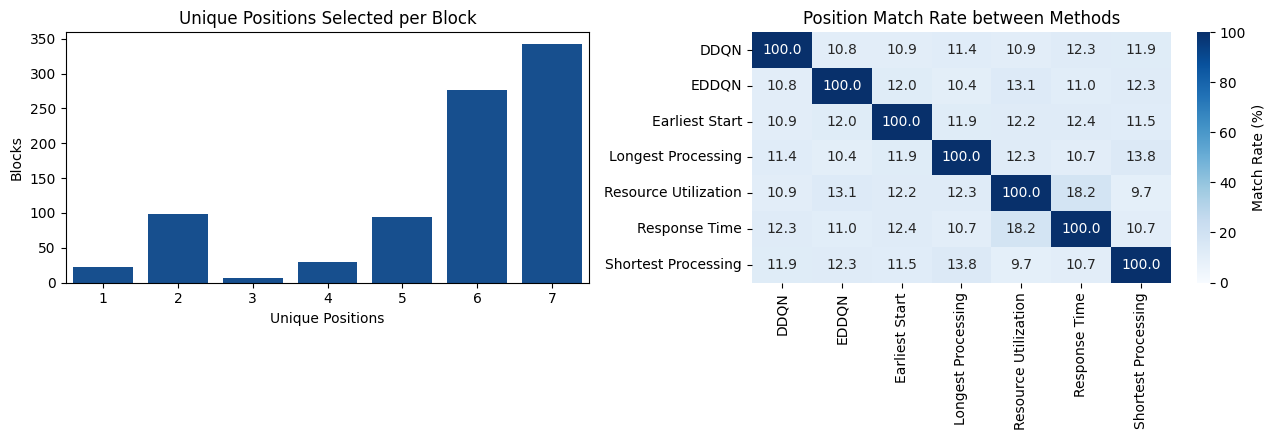

In [4]:
# ============================================================
# 선택 Position 차이 시각화
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)


# Block별로 몇 종류의 Position이 선택되었는지 표시
sns.barplot(
    data=position_change_distribution,
    x='Unique Positions',
    y='Blocks',
    ax=axes[0],
    color='#034EA2'
)

axes[0].set_title(
    'Unique Positions Selected per Block'
)


# 두 방법이 같은 Position을 선택한 비율 표시
sns.heatmap(
    position_match_rate * 100,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100,
    ax=axes[1],
    cbar_kws={'label': 'Match Rate (%)'}
)

axes[1].set_title(
    'Position Match Rate between Methods'
)


plt.tight_layout()
plt.show()


### 4.3.2 선택 Position 특성 비교

872개 Block 중 849개는 Scheduling Method에 따라 선택 Position이 달랐다. 342개 Block은 7개 방법이 모두 서로 다른 Position을 선택했고, 모든 방법이 같은 Position을 선택한 Block은 23개뿐이었다.

방법 간 동일 Position 선택률도 대부분 약 10~18%에 머물렀다. 이는 Position이 Block의 고유 속성이 아니라 Scheduling Method의 의사결정 결과라는 점을 직접 보여준다.

다음으로 방법별 사용 Position 수, 면적 여유비율, 인양 부하비율과 Initial 기록 Position 배정 건수를 요약한다. 이는 선택 결과의 분포를 설명하는 지표이며 단독으로 우열을 판정하지 않는다.


In [5]:
# ============================================================
# 방법별 선택 Position 특성 요약
# ============================================================

position_records = []

for method in method_order:
    frame = schedule_frames[method]

    position_records.append({
        'Method': method,
        'Unique_Positions': frame['position_id'].nunique(),
        'Mean_Area_Margin_Ratio': frame[
            'area_margin_ratio'
        ].mean(),
        'Mean_Lifting_Load_Ratio': frame[
            'lifting_load_ratio'
        ].mean(),
        'Initially_Occupied_Assignments': frame[
            'initially_occupied'
        ].sum()
    })

position_summary = pd.DataFrame(position_records)


# 방법별 1차 구역 배정 비율 계산
primary_area_share = pd.crosstab(
    schedule_data['method'],
    schedule_data['position_primary_area'],
    normalize='index'
)

primary_area_share = primary_area_share.reindex(
    method_order
)

position_summary.round(3)


,Method,Unique_Positions,Mean_Area_Margin_Ratio,Mean_Lifting_Load_Ratio,Initially_Occupied_Assignments
0,DDQN,60,0.437,0.553,182
1,EDDQN,60,0.429,0.550,157
2,Earliest Start,60,0.428,0.550,155
3,Longest Processing,60,0.429,0.549,152
4,Resource Utilization,60,0.429,0.549,155
5,Response Time,60,0.429,0.549,161
6,Shortest Processing,60,0.436,0.552,175


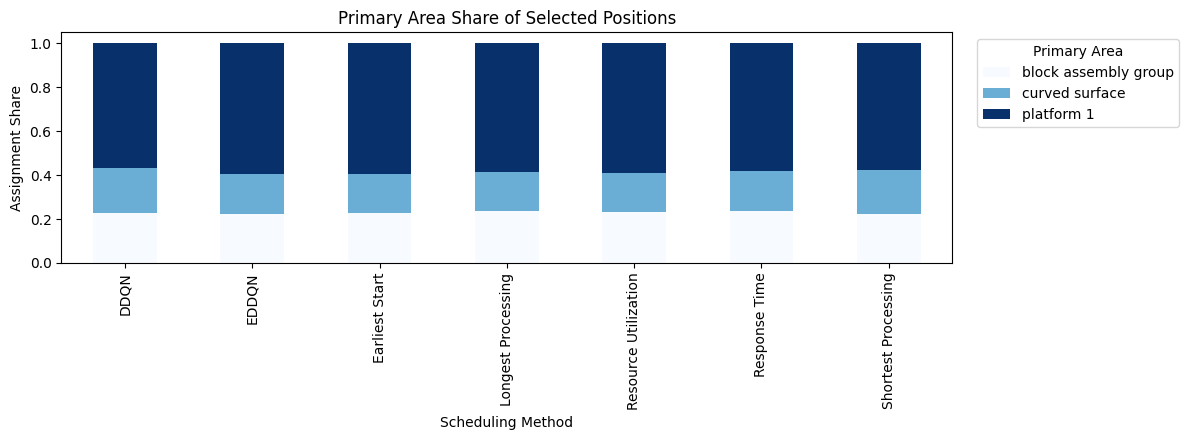

In [6]:
# ============================================================
# 방법별 Position 1차 구역 배정 비율 시각화
# ============================================================

primary_area_share.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 4.5),
    colormap='Blues'
)

plt.ylabel('Assignment Share')
plt.xlabel('Scheduling Method')
plt.title('Primary Area Share of Selected Positions')
plt.legend(
    title='Primary Area',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


### 4.3.3 Position 선택 소결론

- 대부분의 Block은 방법에 따라 서로 다른 Position에 배정된다.
- 7개 방법 모두 60개 Position을 사용했지만, Initial 기록 Position에 배정한 건수와 구역별 배정비율은 달랐다.
- 이 차이는 Scheduling Method가 실제 배치결과를 바꾸는 의사결정 규칙임을 보여준다.
- Position 속성은 선택 결과를 설명하는 데 사용하며, 사전 Cycle 예측변수나 Cycle 변화의 원인으로 해석하지 않는다.


## 4.4 Planned Schedule과 Makespan 비교

각 방법의 가장 이른 Planned Start부터 가장 늦은 Planned Finish까지를 Scheduling Horizon으로 계산한다. 이 프로젝트에서는 이 기간을 Result Table에서 재계산한 Makespan으로 사용한다.


In [7]:
# ============================================================
# 방법별 Planned Schedule과 Makespan 계산
# ============================================================

schedule_records = []

for method in method_order:
    frame = schedule_frames[method]

    # Position별 배정 Block 수 계산
    assignments_per_position = frame.groupby(
        'position_id'
    ).size()

    # 전체 계획의 시작일과 종료일 확인
    schedule_start = frame[
        'planned_start_time'
    ].min()

    schedule_finish = frame[
        'planned_finish_time'
    ].max()

    # 방법별 일정 요약값 저장
    schedule_records.append({
        'Method': method,
        'Schedule_Start': schedule_start,
        'Schedule_Finish': schedule_finish,
        'Makespan_Days': (
            schedule_finish - schedule_start
        ).days,
        'Mean_Planned_Duration': frame[
            'planned_duration_days'
        ].mean(),
        'Used_Positions': frame['position_id'].nunique(),
        'Busiest_Position_Assignments': (
            assignments_per_position.max()
        )
    })


# Makespan이 짧은 방법부터 정렬
schedule_summary = pd.DataFrame(
    schedule_records
).sort_values(
    'Makespan_Days'
).reset_index(drop=True)

schedule_summary


,Method,Schedule_Start,Schedule_Finish,Makespan_Days,Mean_Planned_Duration,Used_Positions,Busiest_Position_Assignments
0,EDDQN,2018-02-24,2022-05-03,1529,25.930046,60,46
1,Earliest Start,2018-03-03,2022-06-16,1566,26.930046,60,46
2,Response Time,2018-04-06,2022-12-30,1729,26.930046,60,48
3,Shortest Processing,2018-04-16,2023-03-13,1792,26.930046,60,57
4,Resource Utilization,2018-04-06,2023-03-04,1793,26.930046,60,47
5,Longest Processing,2018-03-03,2023-03-22,1845,26.930046,60,46
6,DDQN,2018-03-26,2023-09-16,2000,26.930046,60,57


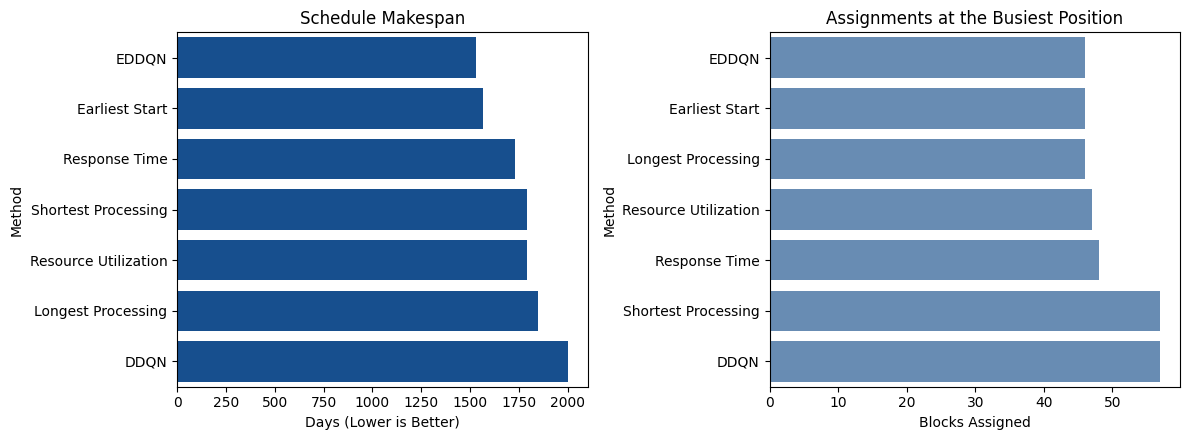

In [8]:
# ============================================================
# Makespan과 Position 집중도 시각화
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)


# 전체 일정 범위인 Makespan 비교
sns.barplot(
    data=schedule_summary,
    x='Makespan_Days',
    y='Method',
    ax=axes[0],
    color='#034EA2'
)

axes[0].set_title('Schedule Makespan')
axes[0].set_xlabel('Days (Lower is Better)')


# 가장 많이 사용된 Position의 배정 Block 수 비교
position_load = schedule_summary.sort_values(
    'Busiest_Position_Assignments'
)

sns.barplot(
    data=position_load,
    x='Busiest_Position_Assignments',
    y='Method',
    ax=axes[1],
    color='#5B8CC0'
)

axes[1].set_title(
    'Assignments at the Busiest Position'
)
axes[1].set_xlabel('Blocks Assigned')


plt.tight_layout()
plt.show()


### 4.4.1 Planned Schedule 소결론

- EDDQN의 재계산 Makespan이 가장 짧고 Earliest Start가 그다음이다.
- 모든 방법이 60개 Position을 사용하지만 가장 많이 사용된 단일 Position의 배정량은 방법별로 다르다.
- Makespan은 전체 일정 범위를, Position 배정량은 공간 사용 분포를 설명한다. 둘은 서로 다른 운영 관점이다.


## 4.5 Delay 성과 비교

`delay days`가 양수이면 지연, 0 이하이면 정시 또는 조기 완료다. 음수 조기 완료가 양수 지연을 상쇄하지 않도록 집계용 Delay는 `max(delay days, 0)`으로 계산한다.

- Total Delay: 양수 Delay의 합
- Mean Delay per Block: 전체 Block 기준 평균 양수 Delay
- Delayed Blocks / Rate: Delay가 양수인 Block 수와 비율
- Max Delay: 가장 큰 지연일수


In [9]:
# ============================================================
# 방법별 Delay 성과 계산
# ============================================================

# Delay 비교에 필요한 컬럼만 선택
delay_detail = schedule_data[
    [
        'method',
        'block_index',
        'position_id',
        'delay_days'
    ]
].copy()


# 음수는 조기 완료이므로 누적지연 계산에서는 0으로 처리
delay_detail['positive_delay'] = delay_detail[
    'delay_days'
].clip(lower=0)

# Delay가 양수인 Block을 지연 Block으로 표시
delay_detail['is_delayed'] = delay_detail[
    'delay_days'
].gt(0)


delay_records = []

for method in method_order:
    group = delay_detail[
        delay_detail['method'] == method
    ]

    delayed = group.loc[
        group['is_delayed'],
        'delay_days'
    ]

    delay_records.append({
        'Method': method,
        'Total_Delay': group['positive_delay'].sum(),
        'Mean_Delay_per_Block': group[
            'positive_delay'
        ].mean(),
        'Mean_Delay_among_Delayed': delayed.mean(),
        'Delayed_Blocks': group['is_delayed'].sum(),
        'Delay_Rate': group['is_delayed'].mean(),
        'Max_Delay': group['delay_days'].max(),
        'On_Time_or_Early_Blocks': (
            ~group['is_delayed']
        ).sum()
    })


# Total Delay가 낮은 방법부터 정렬
delay_summary = pd.DataFrame(
    delay_records
).sort_values(
    'Total_Delay'
).reset_index(drop=True)

delay_summary.round(3)


,Method,Total_Delay,Mean_Delay_per_Block,Mean_Delay_among_Delayed,Delayed_Blocks,Delay_Rate,Max_Delay,On_Time_or_Early_Blocks
0,Earliest Start,57827,66.315,124.896,463,0.531,1145,409
1,EDDQN,66209,75.928,137.079,483,0.554,1096,389
2,Shortest Processing,192289,220.515,281.949,682,0.782,1607,190
3,Response Time,216055,247.769,296.372,729,0.836,1560,143
4,Resource Utilization,216138,247.865,290.899,743,0.852,1547,129
5,Longest Processing,244360,280.229,333.825,732,0.839,1735,140
6,DDQN,251448,288.358,339.795,740,0.849,1765,132


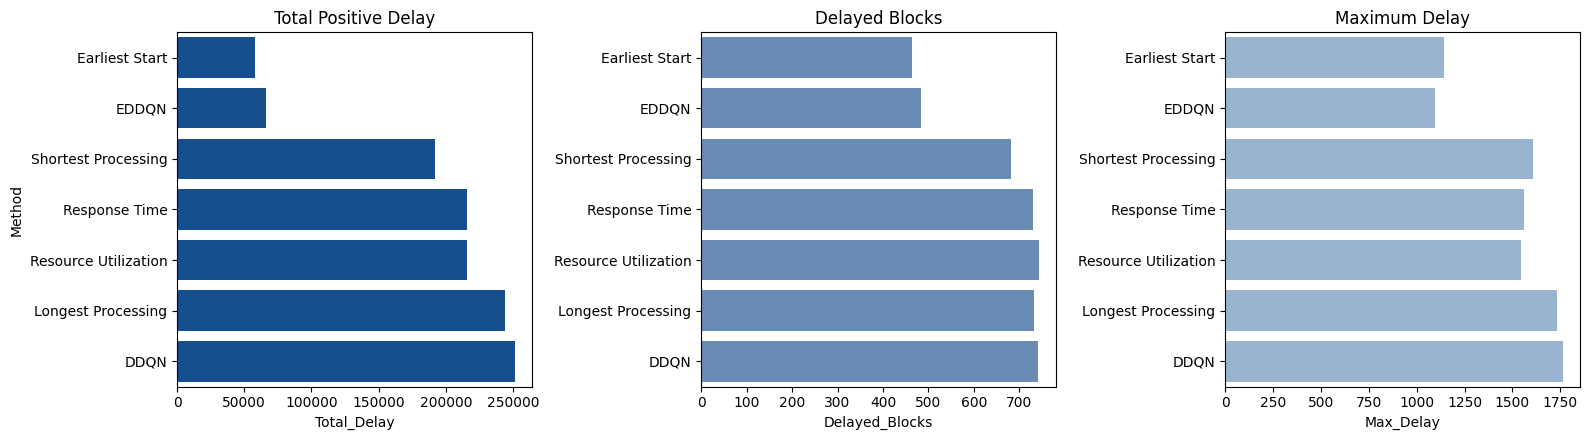

In [10]:
# ============================================================
# Delay 성과 시각화
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5)
)


# 누적 양수 Delay 비교
sns.barplot(
    data=delay_summary,
    x='Total_Delay',
    y='Method',
    ax=axes[0],
    color='#034EA2'
)
axes[0].set_title('Total Positive Delay')


# 지연이 발생한 Block 수 비교
sns.barplot(
    data=delay_summary,
    x='Delayed_Blocks',
    y='Method',
    ax=axes[1],
    color='#5B8CC0'
)
axes[1].set_title('Delayed Blocks')
axes[1].set_ylabel('')


# 가장 큰 단일 Delay 비교
sns.barplot(
    data=delay_summary,
    x='Max_Delay',
    y='Method',
    ax=axes[2],
    color='#8FB4D9'
)
axes[2].set_title('Maximum Delay')
axes[2].set_ylabel('')


plt.tight_layout()
plt.show()


### 4.5.1 Delay 결과

- **Earliest Start**: Total Delay와 Delayed Blocks가 가장 낮다.
- **EDDQN**: Total Delay 2위이며 Max Delay가 가장 낮다.
- **DDQN**: 이번 Result 직접 집계에서는 Total Delay와 Max Delay가 가장 크다.

Delay 지표끼리도 평가대상이 다르다. 누적 지연을 줄이는 방법과 최악의 단일 지연을 억제하는 방법이 반드시 같지는 않다.


### 4.5.2 데이터셋 게시자 성능표와 비교

게시자 성능표는 Makespan, Delayed Blocks, Average Delay Time, Average Turnover Rate, Normalized Average Utilization을 사용한다. 게시자 결과에서 EDDQN은 Makespan·Turnover·Utilization 1위, Delayed Blocks·Average Delay Time 2위로 보고되었다.

본 프로젝트의 Result 직접 집계에서도 EDDQN은 Makespan과 Max Delay가 가장 낮고 Total Delay는 2위였다. Earliest Start는 Total Delay와 Delayed Blocks가 가장 낮았다. 지표 정의와 집계 범위를 확인한 뒤 목적에 맞게 방법을 선택해야 한다.


| 게시자 평가축 | EDDQN 결과 | 본 프로젝트의 확인 범위 |
|---|---|---|
| Makespan | 1위 | Result 재계산에서도 가장 짧음 |
| Delayed Blocks / Average Delay | 2위 | Earliest Start 다음의 상위권 |
| Turnover / Utilization | 1위 | 원 성능표를 참고하며 별도 재계산하지 않음 |

> 게시자 지표와 본 프로젝트의 직접 집계는 정의가 다를 수 있으므로 값 자체를 합산하지 않는다.


## 4.6 결과 저장

Position 배정, 계획일정 요약과 Delay 상세·요약 결과를 저장한다. 논리구조 수정 이전의 `4_prediction_*`과 Cycle Stability 산출물은 더 이상 생성하지 않는다.


In [11]:
# ============================================================
# Scheduling 비교 결과 저장
# ============================================================

# Position 비교 결과 저장
position_assignments.reset_index().to_csv(
    OUTPUT_DIR / '4_position_assignments.csv',
    index=False,
    encoding='utf-8-sig'
)

position_match_rate.to_csv(
    OUTPUT_DIR / '4_position_match_rate.csv',
    encoding='utf-8-sig'
)

position_summary.to_csv(
    OUTPUT_DIR / '4_position_summary.csv',
    index=False,
    encoding='utf-8-sig'
)

primary_area_share.to_csv(
    OUTPUT_DIR / '4_primary_area_share.csv',
    encoding='utf-8-sig'
)


# Planned Schedule 비교 결과 저장
schedule_data.to_csv(
    OUTPUT_DIR / '4_schedule_detail.csv',
    index=False,
    encoding='utf-8-sig'
)

schedule_summary.to_csv(
    OUTPUT_DIR / '4_schedule_summary.csv',
    index=False,
    encoding='utf-8-sig'
)


# Delay 비교 결과 저장
delay_detail.to_csv(
    OUTPUT_DIR / '4_delay_detail.csv',
    index=False,
    encoding='utf-8-sig'
)

delay_summary.to_csv(
    OUTPUT_DIR / '4_delay_summary.csv',
    index=False,
    encoding='utf-8-sig'
)


# 전체 비교 결과에서 발표에 사용할 핵심값 정리
comparison_summary = {
    'comparison_unit': 'precomputed Scheduling Result',
    'blocks': int(len(block)),
    'blocks_with_different_positions': int(changed_blocks),
    'best_makespan_method': schedule_summary.loc[
        0,
        'Method'
    ],
    'lowest_makespan_days': int(
        schedule_summary.loc[0, 'Makespan_Days']
    ),
    'best_total_delay_method': delay_summary.loc[
        0,
        'Method'
    ],
    'lowest_total_delay': float(
        delay_summary.loc[0, 'Total_Delay']
    ),
    'lowest_max_delay_method': delay_summary.sort_values(
        'Max_Delay'
    ).iloc[0]['Method']
}


# 핵심 요약을 JSON 파일로 저장
with open(
    OUTPUT_DIR / '4_comparison_summary.json',
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        comparison_summary,
        file,
        ensure_ascii=False,
        indent=2
    )


print('04 비교 결과 저장 완료')
print(
    json.dumps(
        comparison_summary,
        ensure_ascii=False,
        indent=2
    )
)


04 비교 결과 저장 완료
{
  "comparison_unit": "precomputed Scheduling Result",
  "blocks": 872,
  "blocks_with_different_positions": 849,
  "best_makespan_method": "EDDQN",
  "lowest_makespan_days": 1529,
  "best_total_delay_method": "Earliest Start",
  "lowest_total_delay": 57827.0,
  "lowest_max_delay_method": "EDDQN"
}


## 4.7 결론

- 872개 Block 중 849개는 Scheduling Method에 따라 선택 Position이 달랐다.
- EDDQN은 가장 짧은 Makespan과 가장 낮은 Max Delay를 보였다.
- Earliest Start는 Total Delay와 Delayed Blocks에서 가장 우수했다.
- 어떤 방법이 좋은지는 Makespan, 누적지연, 최악지연, Position 사용 등 목적함수에 따라 달라진다.
- Cycle은 모든 방법에 공통인 사전 입력이므로 방법별 Cycle 예측 RMSE를 Scheduling 성과로 사용하지 않는다.

### 4.7.1 핵심 결론

> **머신러닝은 Block 고유 특성으로 사전 Cycle을 예측하고, Scheduling 평가는 알고리즘이 실제로 만든 Position·시간·Delay 결과로 수행해야 한다.**

이번 수정으로 예측 단계와 최적화 결과 비교 단계를 분리했으며, EDDQN의 강점은 Cycle Stability가 아니라 Result에서 직접 확인되는 Makespan·Max Delay와 게시자 원 평가축으로 설명한다.
